In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

In [2]:
plt.style.use("ggplot")

## Discrete Fourier Transform

Introduction to concept by doing a brute force calculation of the Fourier Transform of $signal(t) = 2.5\sin(2\pi4t) + 1.5\sin(2\pi6.5t)$ and demonstrating how it can be used to reconstruct the original signal.


In [21]:
sampling_rate = 1000 # Hz
sample_length = 2.0 # seconds
t = np.arange(0, sample_length, 1/sampling_rate)
N = len(t)
signal = 2.5*np.sin(2*np.pi*4*t) + 1.5*np.sin(2*np.pi*6.5*t) # Sampled signal

In [5]:
normalized_time = np.arange(0, N)/N
fourier_coefficients = np.array([np.dot(signal, np.exp(-1j*2*np.pi*k*normalized_time)) for k in range(N)])

In [6]:
reconstructed = np.zeros(N)
for freq, coeff in enumerate(fourier_coefficients):
    frequency_component = coeff*np.exp(1j*2*np.pi*freq*normalized_time)
    reconstructed = np.add(reconstructed, frequency_component)
reconstructed *= (1/N)

In [13]:
significant = np.where(np.abs(fourier_coefficients) > 1e-6)[0]
print(significant, "→", significant * sampling_rate / N, "Hz")

[   8   13 1987 1992] → [  4.    6.5 993.5 996. ] Hz


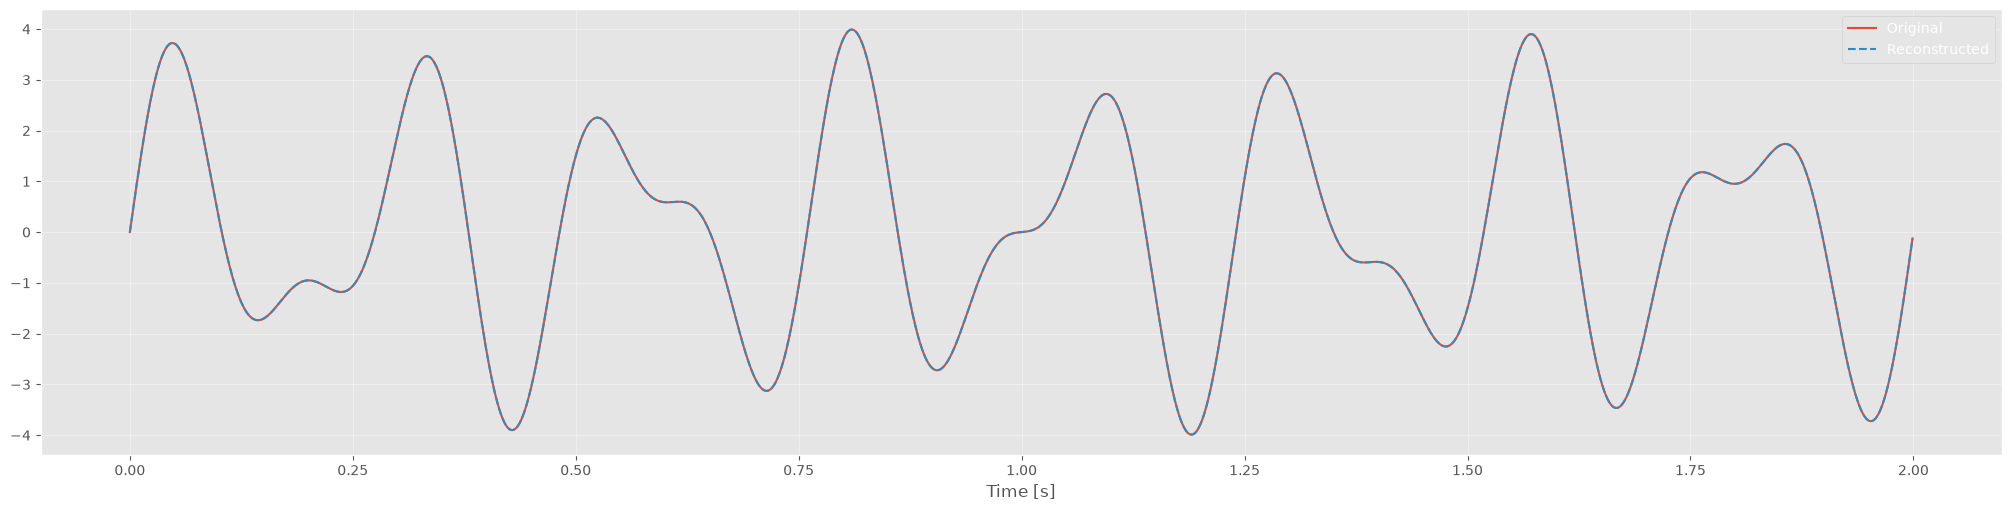

In [14]:
fig, ax = plt.subplots(figsize=(20, 5), constrained_layout=True)
ax.plot(t, signal, label="Original")
ax.plot(t, reconstructed.real, "--", label="Reconstructed")
ax.set_xlabel("Time [s]")
ax.legend()
plt.show()

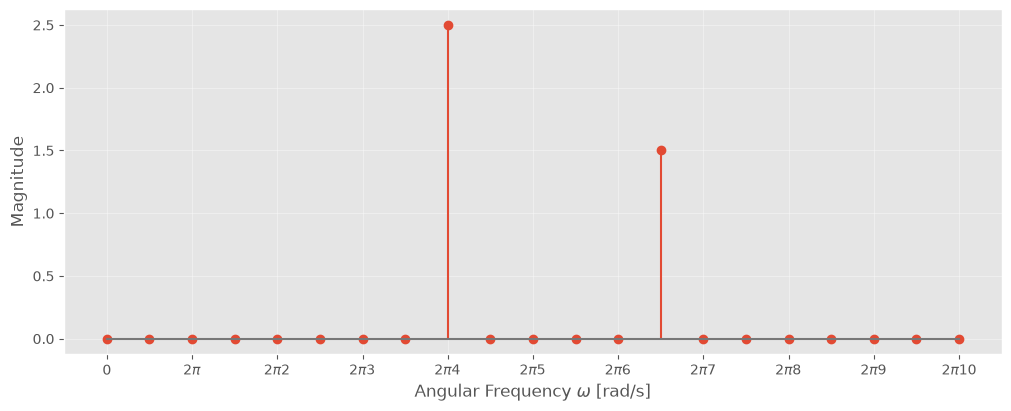

In [27]:
freqs_hz = np.arange(N) * sampling_rate /N
max_freq_hz = 10
n = int((max_freq_hz/sampling_rate)*N) + 1

angular_freq = 2 * np.pi * freqs_hz[:n]
magnitude = (2*np.abs(fourier_coefficients[:n]))/N
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.stem(angular_freq, magnitude, label="Magnitude")

# Format ticks as multiples of π
def pi_formatter(x, pos):
    if x == 0:
        return "0"
    n = x / (2*np.pi)
    if np.isclose(n, 1):
        return r"$2\pi$"
    if np.isclose(n, -1):
        return r"$-2\pi$"
    if np.isclose(n, round(n)):
        return rf"$2\pi{int(round(n))}$"
    return rf"$2\pi{n:.1f}$"

ax.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
ax.xaxis.set_major_locator(MultipleLocator(2 * np.pi))  # tick every 2π
ax.set_xlabel(r"Angular Frequency $\omega$ [rad/s]")
ax.set_ylabel("Magnitude");